Some modifications I am making to my volumeHT
1. Want to adjust volumeHT so that was can choose our coordinates for
the overall space not just the side length. Like we won't assume that
each side ranges from -L/2 to L/2
2. add the box's center as an object variable an then add the fromCenter
method.

In [1]:
import numpy
import boxes

In [59]:

class volumeHT:
    
    def __init__(self, spaceCoordinates, c, d, boxType, listOfParticleTypes = None):
        self.boxType = boxType
        self.conc = c #concentration
        # spaceCoordinates should give the coordinates of the overall
        # volume in space. Should be in the form [xmin, xmax, ymin, ymax,
        # zmin, zmax]
        self.spaceCoordinates = tuple(spaceCoordinates)
        lengths = []
        for i in range(3):
            lengths.append(spaceCoordinates[2*i + 1] - spaceCoordinates[2*i])
        self.lengths = tuple(lengths) #save all dimensions for iterating
        tempS = numpy.cbrt(d/c) #compute the approximate box size using
        # the above formula (temp here is temporary not temperature)
        s = [] #save the actual box dimensions
        numberOfBoxes = []
        for length in self.lengths: #follow above formula to find
                                    # integer number of boxes in each dimension
            b = int(numpy.round(length/tempS))
            if b == 0:
                b = 1
            sDim = length/b #also find real box length
            numberOfBoxes.append(b) #save these values
            s.append(sDim)
        self.numberOfBoxesPerDim = tuple(numberOfBoxes) #save to object variable
        self.sideLengths = tuple(s) #these are the box lengths
        self.density = self.conc * self.lengths[0]*self.lengths[1]*self.lengths[2]/(self.numberOfBoxesPerDim[0]*self.numberOfBoxesPerDim[1]*self.numberOfBoxesPerDim[2])
        self.boxDict = {}
        for i in range(self.numberOfBoxesPerDim[0]):
            xcenter = spaceCoordinates[0*2] + i*self.sideLengths[0] + self.sideLengths[0]/2
            for j in range(self.numberOfBoxesPerDim[1]):
                ycenter = spaceCoordinates[1*2] + j*self.sideLengths[1] + self.sideLengths[1]/2
                for k in range(self.numberOfBoxesPerDim[2]):
                    zcenter = spaceCoordinates[2*2] + k*self.sideLengths[2] + self.sideLengths[2]/2
                    self.boxDict[(i, j, k)] = boxType((i, j, k), (xcenter, ycenter, zcenter), self.sideLengths, listOfParticleTypes)
    
    # find the box corresponding to the coordinates
    def coordsToBox(self, coords):
        boxCoords = []
        # subtract the minimum (x, y, z) in the box, beaucse boxes start counting at zero
        coords = coords - numpy.array([self.spaceCoordinates[0],
                                       self.spaceCoordinates[2], self.spaceCoordinates[4]])
        for i in range(3):
            boxCoords.append(numpy.floor(coords[i]/self.sideLengths[i]))
        return self.boxDict[tuple(boxCoords)] #everything has to happen in tuple; numpy
    # arrays are not hashable
    
    # is a given coordinate in this box
    def inBox(self, coord):
        for i in range(3):
            if not (coord[i] >= self.spaceCoordinates[2*i] and coord[i] <= self.spaceCoordinates[2*i + 1]):
                return False
        return True
    
    
    # dimension is the axis on which the surface lies (ie x, y, or z);
    # direction is whether the cell is above the surface (direction > 0)
    # or below the surface (direction < 0)
    # coord is teh dimension - coordinate whther it lies
    def getSurfaceBoxes(self, dimension, direction, coord):
        assert (dimension >= 0 and dimension <= 2), "dimension must be 0, 1, or 2"
        inBox = coord >= self.spaceCoordinates[2*dimension] and coord <= self.spaceCoordinates[2*dimension + 1]
        assert inBox, " surface must be in the box "
        coord = coord - self.spaceCoordinates[2*dimension]
        boxCoord = numpy.floor(coord/self.sideLengths[dimension])
        if boxCoord == coord/self.sideLengths[dimension] and direction<= 0:
            boxCoord -=1
        print("boxCoord = " + str(coord/self.sideLengths[dimension]))
        surfaceBoxes = {}
        for boxTuple in self.boxDict:
            if boxTuple[dimension] == boxCoord:
                surfaceBoxes[boxTuple] = self.boxDict[boxTuple]
        if len(surfaceBoxes) == 0:
            raise Exception(" not in box ")
        return surfaceBoxes
        
        
    
    #find the adjacent boxes
    def adjacent(self, box):
        lst = []
        boxNum = box.boxNumber
        for i in [-1, 0, 1]:
            new_x = boxNum[0] + i
            if new_x < 0 or new_x >= self.numberOfBoxesPerDim[0]:
                continue
            for j in [-1, 0, 1]:
                new_y = boxNum[1] + j
                if new_y < 0 or new_y >= self.numberOfBoxesPerDim[1]:
                    continue
                for k in [-1, 0, 1]:
                    new_z = boxNum[2] + k
                    if new_z < 0 or new_z >= self.numberOfBoxesPerDim[2]:
                        continue
                    if (i, j, k) != (0, 0, 0):
                        lst.append(self.boxDict[(new_x, new_y, new_z)])
        return lst 
    
    # put a particle in the hash table, check for collisions
    def put(self, item):
        coord = item.pos
        assert self.inBox(coord), " position not in volumeHT "
        box = self.coordsToBox(coord)
        # we don't need to check collision if in bulk region
        if (self.boxType == boxes.overlapBox) or (self.boxType == boxes.augOverlapBox):
            box.add(item)
            return True
        # must check for collision
        # first check if overlaps with any other particles in the box
        allowed = box.allowedMoveInBox(item, coord)
        if not allowed:
            return False
        # if the particle is close enough to the center of the box,
        # particles in adjacent boxes need not be checked
        if box.fromCenter(coord, item.rad):
            box.add(item)
            return True
        # if the particle is outside the box's center orbit, we must
        # check the particles in adjacent boxes for collision
        adjacentBoxes = self.adjacent(box)
        for b in adjacentBoxes:
            if not b.allowedMoveOutOfBox(item, coord):
                return False
        # if it does not collide with the partilces in adjacent boxes,
        # move the particle and return True
        box.add(item)
        return True
        
    
    # deletes an item from the hash table
    def delete(self, item):
        box = self.coordsToBox(item.pos)
        box.delete(item)
    
    # get a list of all particles in the HashTable
    def contents(self):
        allItems = []
        allBoxes = self.boxDict.values()
        for box in allBoxes:
            for ob in box.contents:
                allItems.append(ob)
        return allItems
    
    # attempt to move the particle item to the coordinate newPos
    # particle is deleted and readded for rehashing
    # if succeeds return True; otherwise return False
    def attemptMove(self, item, newPos):
        # save the old coord in case the move fails (ie collision)
        oldPos = item.pos
        # delete the particle for rehashing
        self.delete(item)
        # update the position
        item.pos = newPos
        # rehash, checking for collisions
        if self.put(item):
            return True
        # if fails, return to old coordinates and readd to box
        item.pos = oldPos
        oldBox = self.coordsToBox(oldPos)
        # don't bother with checking for collisions with whole put()
        # regimen if just undoing
        oldBox.add(item)
        return False

Now I need to test this code!

Boo!

I'm going to start by checking the volumeHT constructor

In [3]:
# I need to write a function that checks the constructor

# first I will try a very simple case. I have a cube of sidelength 3,
# going from 0 to 3 on each side, and my concentration and density are 1
from matplotlib import pyplot as plt

volumeHTsimple = volumeHT([0, 3, 0, 3, 0, 3], 1, 1, boxes.radiusBox)
def printBoxInfo(vht):
    for box in vht.boxDict.values():
        print("Box Number: " + str(box.boxNumber))
        print("center: " + str(box.center))
        print("side lengths: " + str(box.sideLengths))
        print('\n')
    


In [ ]:

# still making functionality to check the box method
def drawBox(box, graph, xaxisdimension, yaxisdimension):
    xcenter = box.center[xaxisdimension]
    ycenter = box.center[yaxisdimension]
    xlength = box.sideLengths[xaxisdimension]
    ylength = box.sideLengths[yaxisdimension]
    xmn = xcenter - xlength/2
    xmx = xcenter + xlength/2
    ymn = ycenter - ylength/2
    ymx = ycenter + ylength/2
    graph.plot((xmn, xmn), (ymn, ymx), 'k-') # left line
    graph.plot((xmx, xmx), (ymn, ymx), 'k-') # right line
    graph.plot((xmn, xmx), (ymn, ymn), 'k-') # bottom line
    graph.plot((xmn, xmx), (ymx, ymx), 'k-') # top line

# grapher item for boxes
#not going to use 3d plotter, just will plot each direction
def constructorChecker(volumeHT):
    print("actual density: " + str(volumeHT.density))
    print("side lengths: " + str(volumeHT.sideLengths))
    print("number of boxes per dimension" + str(volumeHT.numberOfBoxesPerDim))
    fig, axes = plt.subplots(3, 1)
    fig.set_figwidth(numpy.sum(volumeHT.lengths))
    fig.set_figheight(numpy.sum(volumeHT.lengths)*2.6)
    radius = numpy.min(volumeHT.sideLengths)/2
    for box in volumeHT.boxDict.values():
        cent = box.center
        for i in range(3):
            drawBox(box, axes[i], i, (i+1) % 3)
            circle = plt.Circle([cent[i], cent[(i+1)%3]], radius, fill = False)
            axes[i].add_patch(circle)
    dimensionNumbersToWords = {0: 'x', 1:'y', 2:'z'}
    for i in range(3):
        axes[i].set_xlabel(dimensionNumbersToWords[i])
        axes[i].set_ylabel(dimensionNumbersToWords[(i+1)%3])
    return fig, axes
        
    
def drawParticles2D(graphs, vht):
    parts = vht.contents()
    for part in parts:
        print(part.pos)
        for number in [0, 1, 2]:
            dim1 = number
            dim2 = (number + 1)%3
            position = part.pos
            graphs[number].plot(position[dim1], position[dim2], '.', ms = 10)

def boxChecker(vht):
    boxDict = vht.boxDict
    for key, value in boxDict.items():
        print("key: " + str(key))
        print("center: " + str(value.center))
        print("contents:")
        for part in value.particles():
            print(part.pos)
        print("population: " + str(value.population()))
        print("is empty: " + str(value.isEmpty()))
        print("____________________________\n")
        
def augBoxChecker(vht):
    boxDict = vht.boxDict
    for key, value in boxDict.items():
        print("key: " + str(key))
        print("center: " + str(value.center))
        print("contents:")
        for part in value.particles():
            print(str(part.pos) + "; " + str(part.species))
        print("population: " + str(value.population()))
        for sp, pop in value.speciesCounter.items():
            print("population of " + sp + ": " + str(pop))
        print("is empty: " + str(value.isEmpty()))
        print("____________________________\n")

def moverChecker(vht):
    boxDict = vht.boxDict
    for key, value in boxDict.items():
        if not value.isEmpty():
            print("key: " + str(key))
            print("center: " + str(value.center))
            print("contents:")
            for part in value.particles():
                print(part.pos)
                print("\t in center orbit: " + str(value.fromCenter(part.pos, part.rad)))
            print("population: " + str(value.population()))
            print("____________________________\n")

actual density: 4.8
side lengths: (1.0, 1.0, 0.8)
number of boxes per dimension(2, 2, 5)


(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 0, 4)
(0, 1, 0)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 1, 4)
(1, 0, 0)
(1, 0, 1)
(1, 0, 2)
(1, 0, 3)
(1, 0, 4)
(1, 1, 0)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 1, 4)


boxCoord = 1.875
(0, 0, 1)
(0, 1, 1)
(1, 0, 1)
(1, 1, 1)
[-0.5 -0.5  1.2]
[-0.5  0.5  1.2]
[ 0.5 -0.5  1.2]
[0.5 0.5 1.2]


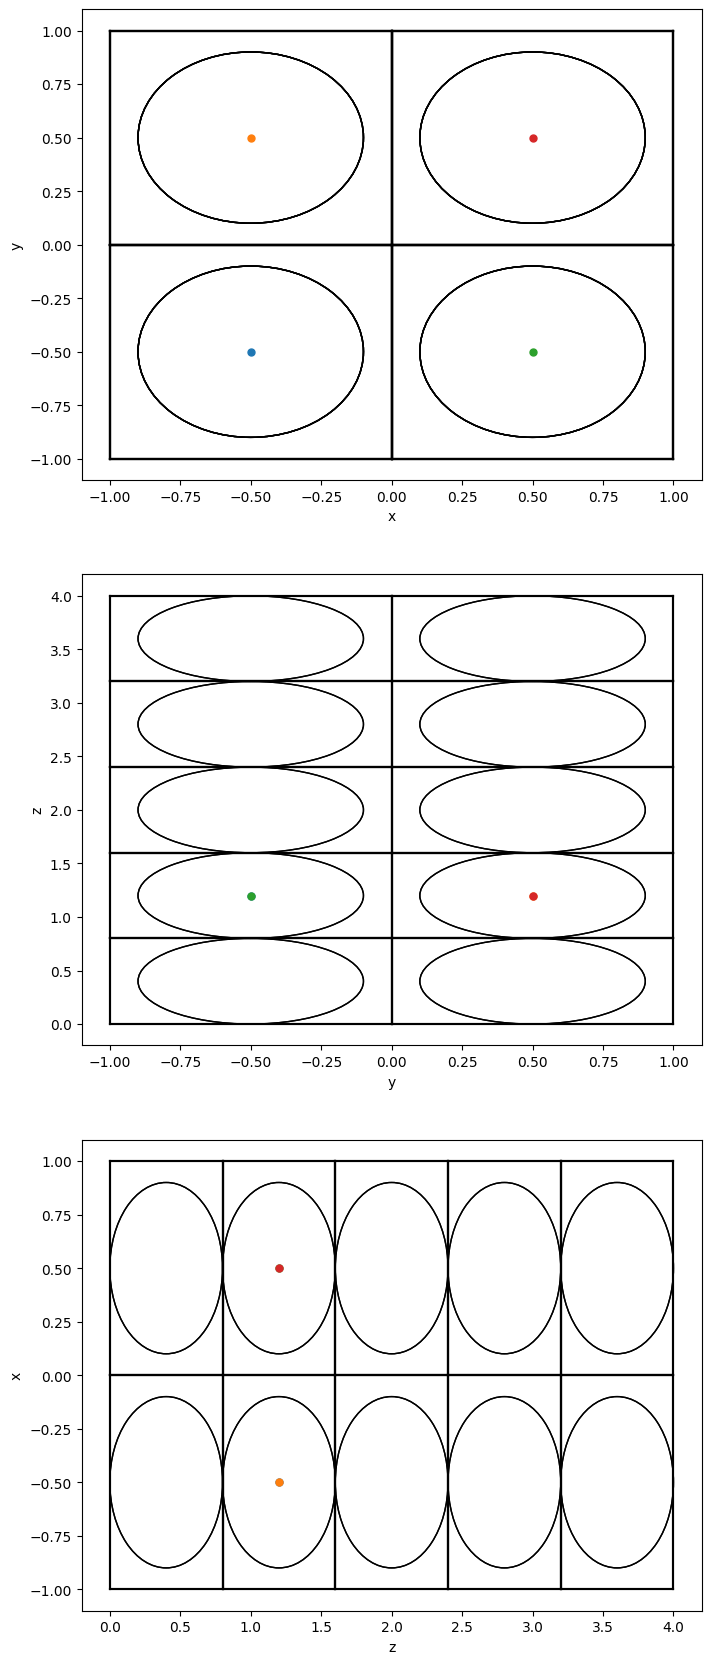

In [66]:
import redoxSimulation as redsim

vht = volumeHT([-1, 1, -1, 1, 0, 4], 6, 4, boxes.radiusBox)
fig, ax = constructorChecker(vht)
print("\n")
for b in vht.boxDict:
    print(b)
print('\n')
for key, value in vht.getSurfaceBoxes(2, -1, 1.5).items():
    print(key)
    vht.put(redsim.molecule(numpy.array(value.center) , '4'))
drawParticles2D(ax, vht)
    

Ok, well, I think I have checked the $\texttt{volumeHT}$ constructor. I still need to
check the $\texttt{box}$ methods as well as the other $\texttt{volumeHT}$ object methods.
Oh, fuck me, I'm going to have to go box by box

Update where I'm at cuz I don't remember anything:

5. check vht adjacent() and contents()

actual density: 16.0
side lengths: (2.0, 2.0, 2.0)
number of boxes per dimension(1, 1, 2)
part1 True
part2: True
part3: True
part4: False
[0. 0. 0.]
[0.9 0.9 0.9]
[ 0.3 -0.4  0.9]


key: (0, 0, 1)
center: (0.0, 0.0, 1.0)
contents:
[0. 0. 0.]
	 in center orbit: False
[0.9 0.9 0.9]
	 in center orbit: False
[ 0.3 -0.4  0.9]
	 in center orbit: True
population: 3
____________________________

True
True
False
actual density: 16.0
side lengths: (2.0, 2.0, 2.0)
number of boxes per dimension(1, 1, 2)
[0. 0. 0.]
[0.9 0.9 0.9]
[ 0.3 -0.4  0.6]


key: (0, 0, 1)
center: (0.0, 0.0, 1.0)
contents:
[0. 0. 0.]
	 in center orbit: False
[0.9 0.9 0.9]
	 in center orbit: False
[ 0.3 -0.4  0.6]
	 in center orbit: True
population: 3
____________________________



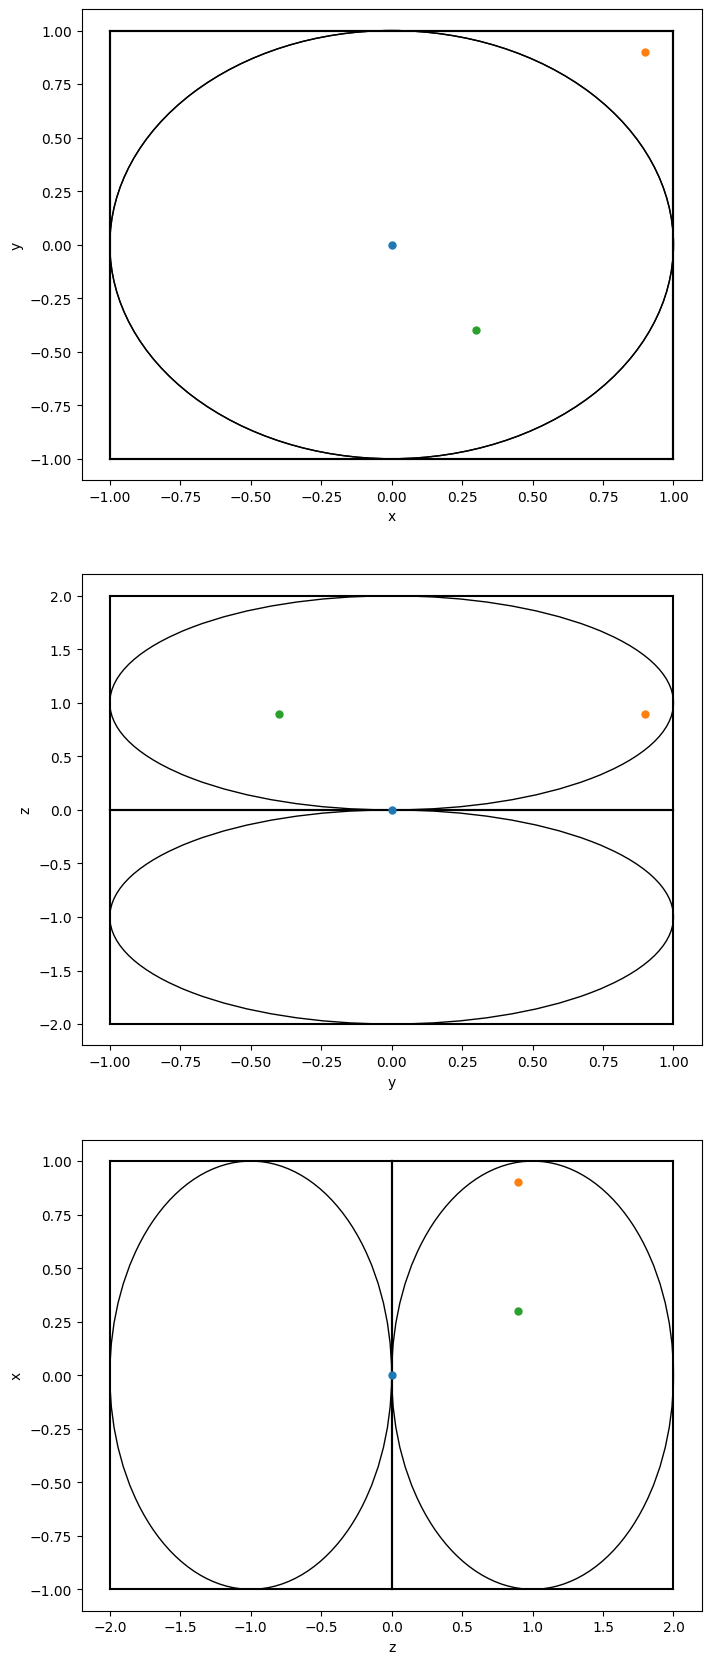

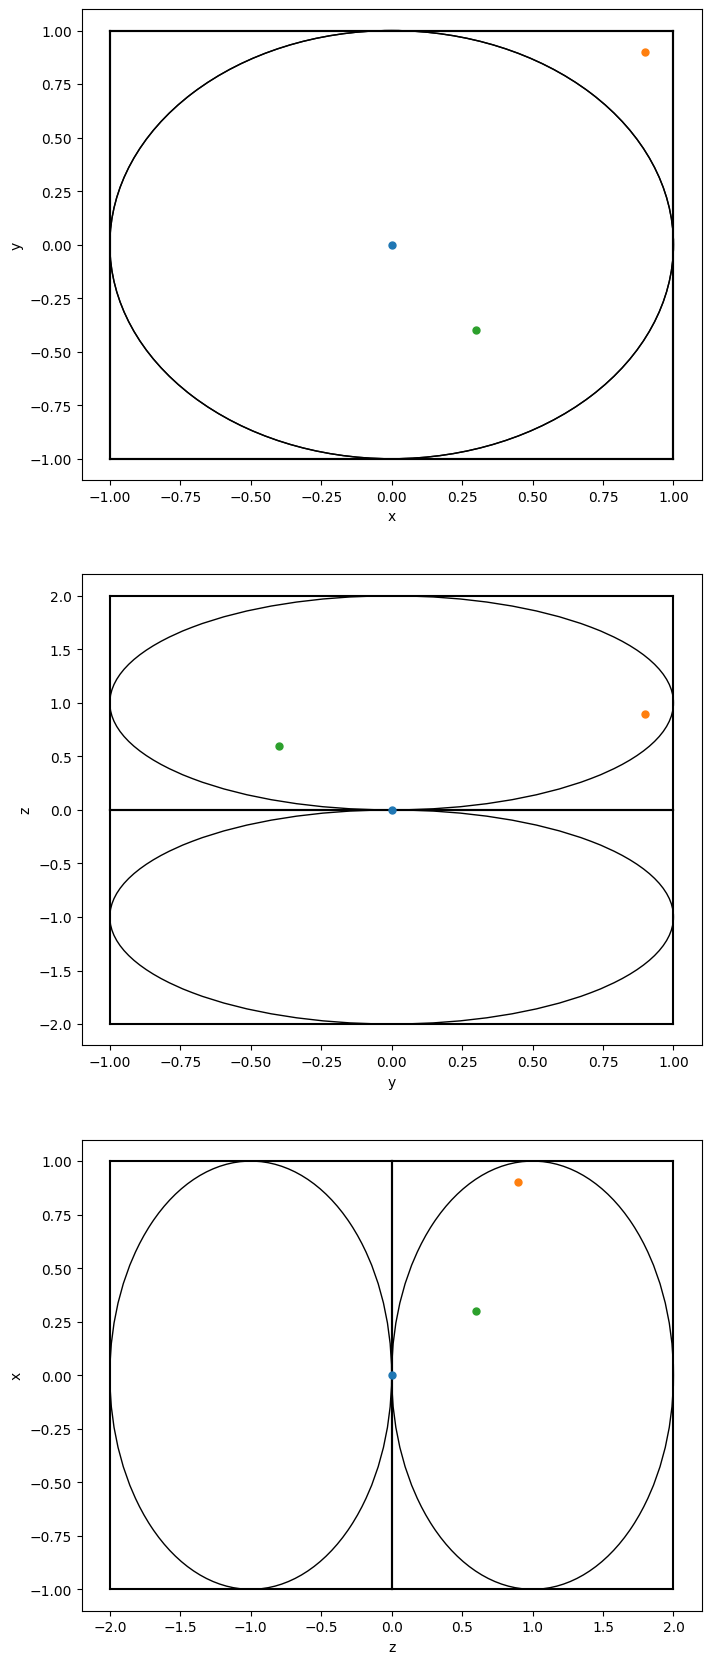

In [6]:
vht = volumeHT([-1, 1, -1, 1, -2, 2], 2, 30, boxes.radiusBox)
fig, ax = constructorChecker(vht)
part1 = redsim.molecule(numpy.array([0.9, 0.9, 0.9]), '3')
print("part1 " + str(vht.put(part1)))
part2 = redsim.molecule(numpy.array([0, 0, 0.0]), '3')
print("part2: " + str(vht.put(part2)))
part3 = redsim.molecule(numpy.array([0.3, -0.4, 0.9]), '3')
print("part3: " + str(vht.put(part3)))
part4 = redsim.molecule(numpy.array([0, 0, -0.1]), '3')
print("part4: " + str(vht.put(part4)))
drawParticles2D(ax, vht)
print("\n")
moverChecker(vht)

print(vht.attemptMove(part3, numpy.array([0.3, -0.4, 0.95])))
print(vht.attemptMove(part3, numpy.array([0.3, -0.4, 0.6])))
print(vht.attemptMove(part2, numpy.array([0.8, 0.8, 0.8])))
fig, ax = constructorChecker(vht)
drawParticles2D(ax, vht)
print("\n")
moverChecker(vht)

actual density: 2.0
side lengths: (1.0, 1.0, 1.0)
number of boxes per dimension(2, 2, 3)

 checking contents()
[0.6  0.97 0.6 ] 0.351 4
[0.3 0.3 0.9] 0.327 3
done checking contents 

checking adjacent()
(0, 0, 1)
	 (0, 0, 0)	(-0.5, -0.5, 0.5)
	 (0, 0, 2)	(-0.5, -0.5, 2.5)
	 (0, 1, 0)	(-0.5, 0.5, 0.5)
	 (0, 1, 1)	(-0.5, 0.5, 1.5)
	 (0, 1, 2)	(-0.5, 0.5, 2.5)
	 (1, 0, 0)	(0.5, -0.5, 0.5)
	 (1, 0, 1)	(0.5, -0.5, 1.5)
	 (1, 0, 2)	(0.5, -0.5, 2.5)
	 (1, 1, 0)	(0.5, 0.5, 0.5)
	 (1, 1, 1)	(0.5, 0.5, 1.5)
	 (1, 1, 2)	(0.5, 0.5, 2.5)
[0.6  0.97 0.6 ]
[0.3 0.3 0.9]


key: (0, 0, 0)
center: (-0.5, -0.5, 0.5)
contents:
population: 0
population of 3: 0
population of 4: 0
is empty: True
____________________________

key: (0, 0, 1)
center: (-0.5, -0.5, 1.5)
contents:
population: 0
population of 3: 0
population of 4: 0
is empty: True
____________________________

key: (0, 0, 2)
center: (-0.5, -0.5, 2.5)
contents:
population: 0
population of 3: 0
population of 4: 0
is empty: True
______________________

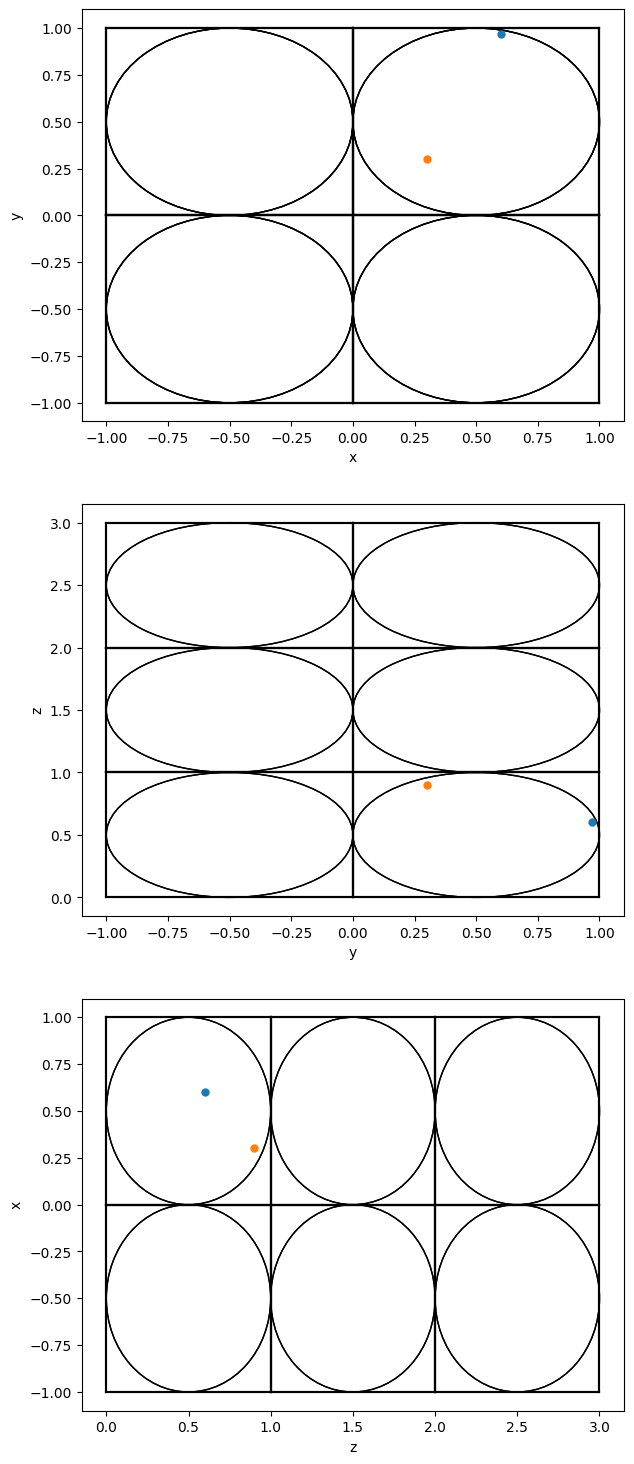

In [7]:
# checking augRadiusBox

vht = volumeHT([-1, 1, -1, 1, 0, 3], 2, 3, boxes.augRadiusBox, ['3', '4'])
fig, ax = constructorChecker(vht)

part1 = redsim.molecule(numpy.array([0.3, 0.3, 0.9]), '3')
vht.put(part1)
part2 = redsim.molecule(numpy.array([0.6, 0.97, 1.6]), '4')
vht.put(part2)
vht.delete(part2)
part2.pos = part2.pos - numpy.array([0, 0, 1.0])
vht.put(part2)

print("\n checking contents()")
cont = vht.contents()
for part in cont:   
    print(part.pos, part.rad, part.species)
print("done checking contents \n")

print("checking adjacent()")
print("(0, 0, 1)")
adj = vht.adjacent(vht.boxDict[(0, 0, 1)])
for a in adj:
    print("\t " + str(a.boxNumber) + "\t" + str(a.center))

drawParticles2D(ax, vht)
print("\n")
augBoxChecker(vht)

actual density: 16.0
side lengths: (2.0, 2.0, 2.0)
number of boxes per dimension(1, 1, 2)
part1 True
part2: True
part3: True
part4: False
[0. 0. 0.]
[0.9 0.9 0.9]
[ 0.3 -0.4  0.9]


key: (0, 0, 1)
center: (0.0, 0.0, 1.0)
contents:
[0. 0. 0.]
	 in center orbit: False
[0.9 0.9 0.9]
	 in center orbit: False
[ 0.3 -0.4  0.9]
	 in center orbit: True
population: 3
____________________________

True
True
False
actual density: 16.0
side lengths: (2.0, 2.0, 2.0)
number of boxes per dimension(1, 1, 2)
[0. 0. 0.]
[0.9 0.9 0.9]
[ 0.3 -0.4  0.6]


key: (0, 0, 1)
center: (0.0, 0.0, 1.0)
contents:
[0. 0. 0.]
	 in center orbit: False
[0.9 0.9 0.9]
	 in center orbit: False
[ 0.3 -0.4  0.6]
	 in center orbit: True
population: 3
____________________________



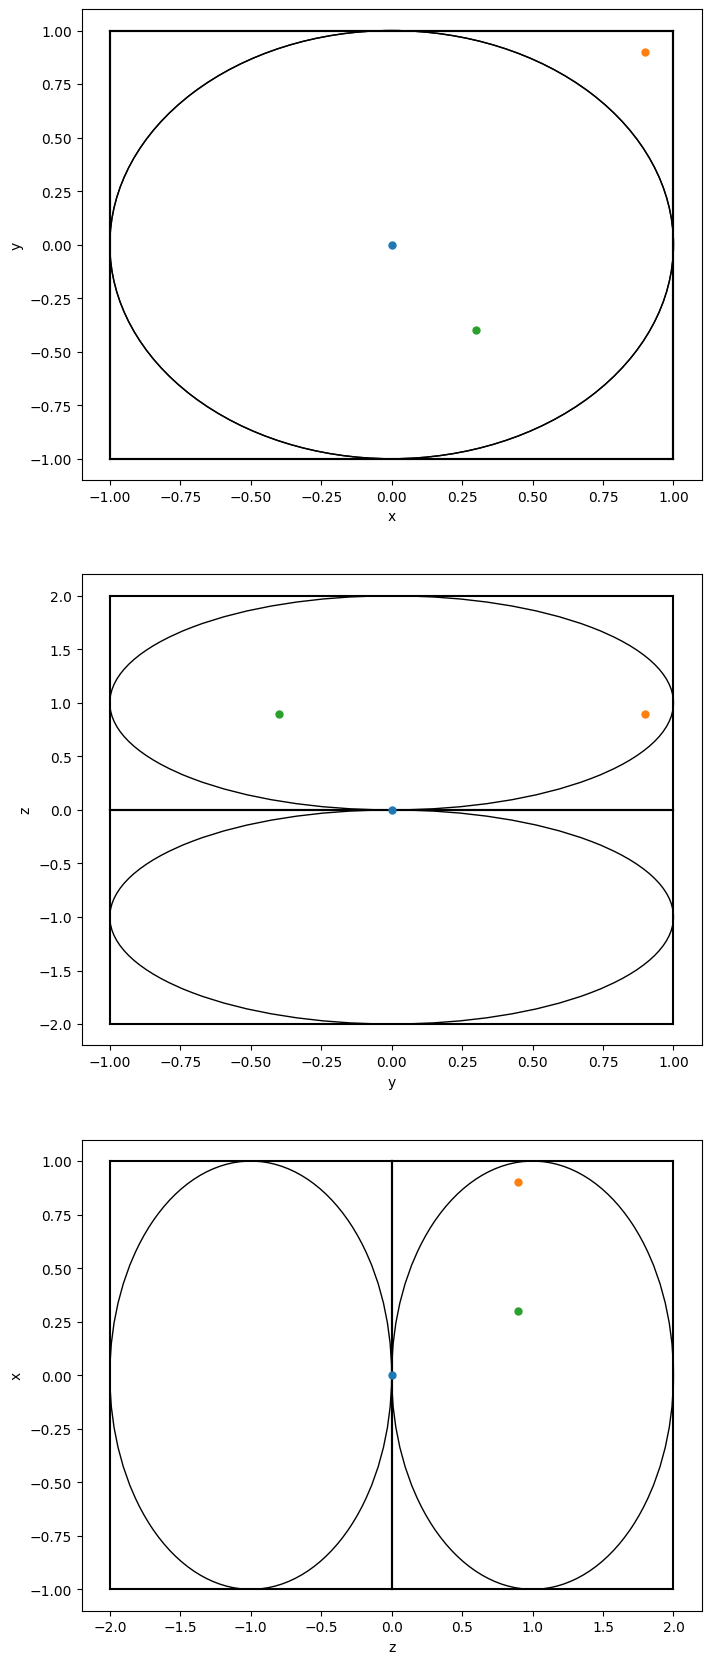

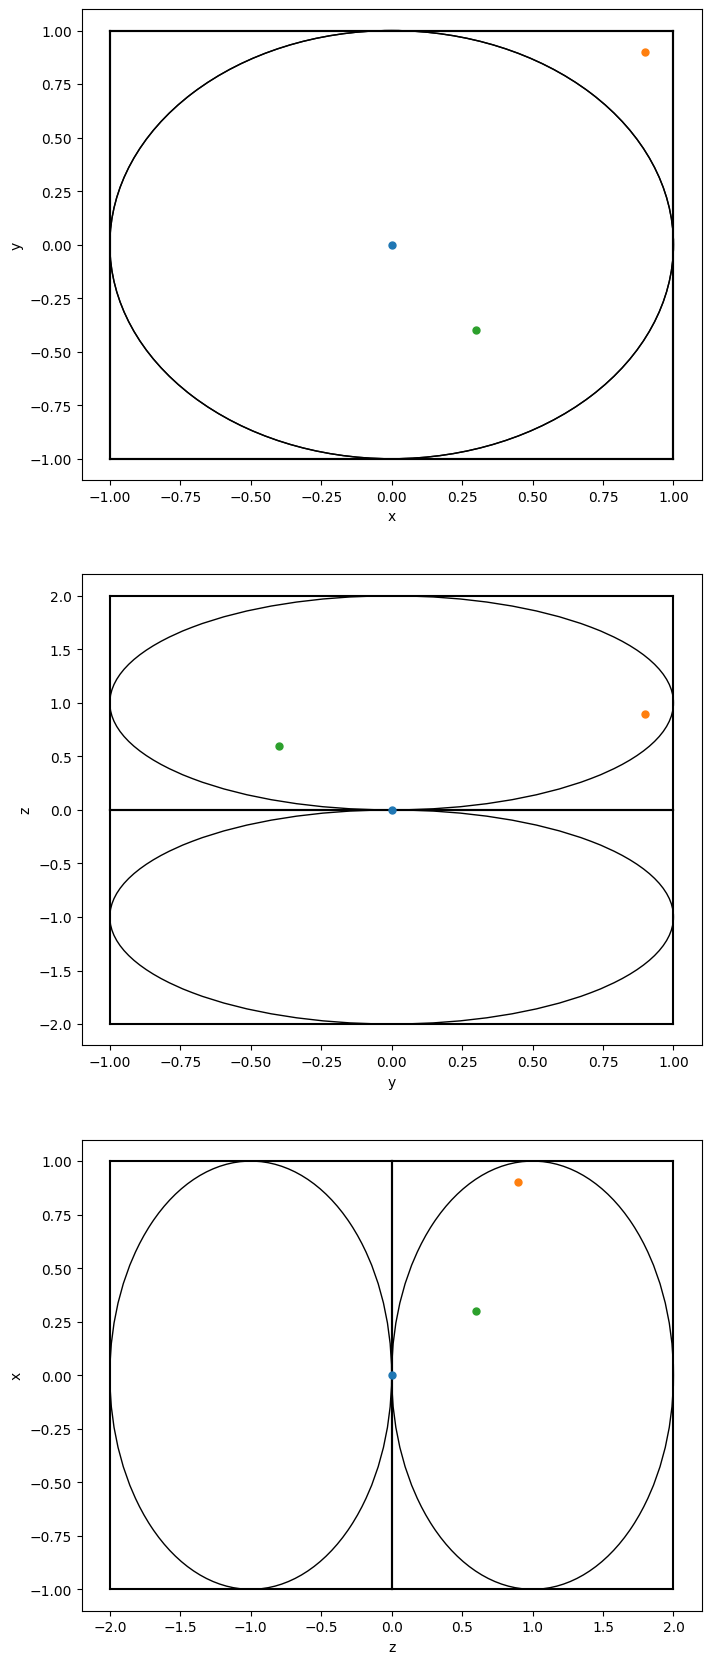

In [8]:
# for the augRadiusBox moverChecker
vht = volumeHT([-1, 1, -1, 1, -2, 2], 2, 30, boxes.augRadiusBox, ['3', '4'])
fig, ax = constructorChecker(vht)
part1 = redsim.molecule(numpy.array([0.9, 0.9, 0.9]), '3')
print("part1 " + str(vht.put(part1)))
part2 = redsim.molecule(numpy.array([0, 0, 0.0]), '4')
print("part2: " + str(vht.put(part2)))
part3 = redsim.molecule(numpy.array([0.3, -0.4, 0.9]), '3')
print("part3: " + str(vht.put(part3)))
part4 = redsim.molecule(numpy.array([0, 0, -0.1]), '4')
print("part4: " + str(vht.put(part4)))
drawParticles2D(ax, vht)
print("\n")
moverChecker(vht)

print(vht.attemptMove(part3, numpy.array([0.3, -0.4, 0.95])))
print(vht.attemptMove(part3, numpy.array([0.3, -0.4, 0.6])))
print(vht.attemptMove(part2, numpy.array([0.8, 0.8, 0.8])))
fig, ax = constructorChecker(vht)
drawParticles2D(ax, vht)
print("\n")
moverChecker(vht)

actual density: 16.0
side lengths: (2.0, 2.0, 2.0)
number of boxes per dimension(1, 1, 2)
part1 True
part2: True
part3: True
part4: True
[ 0.   0.  -0.1]
[0.9 0.9 0.9]
[0. 0. 0.]
[ 0.3 -0.4  0.9]


key: (0, 0, 0)
center: (0.0, 0.0, -1.0)
contents:
[ 0.   0.  -0.1]
population: 1
is empty: False
____________________________

key: (0, 0, 1)
center: (0.0, 0.0, 1.0)
contents:
[0.9 0.9 0.9]
[0. 0. 0.]
[ 0.3 -0.4  0.9]
population: 3
is empty: False
____________________________

True
True
True
actual density: 16.0
side lengths: (2.0, 2.0, 2.0)
number of boxes per dimension(1, 1, 2)
[ 0.   0.  -0.1]
[0.9 0.9 0.9]
[ 0.3 -0.4  0.6]
[0.8 0.8 0.8]


key: (0, 0, 0)
center: (0.0, 0.0, -1.0)
contents:
[ 0.   0.  -0.1]
population: 1
is empty: False
____________________________

key: (0, 0, 1)
center: (0.0, 0.0, 1.0)
contents:
[0.9 0.9 0.9]
[ 0.3 -0.4  0.6]
[0.8 0.8 0.8]
population: 3
is empty: False
____________________________



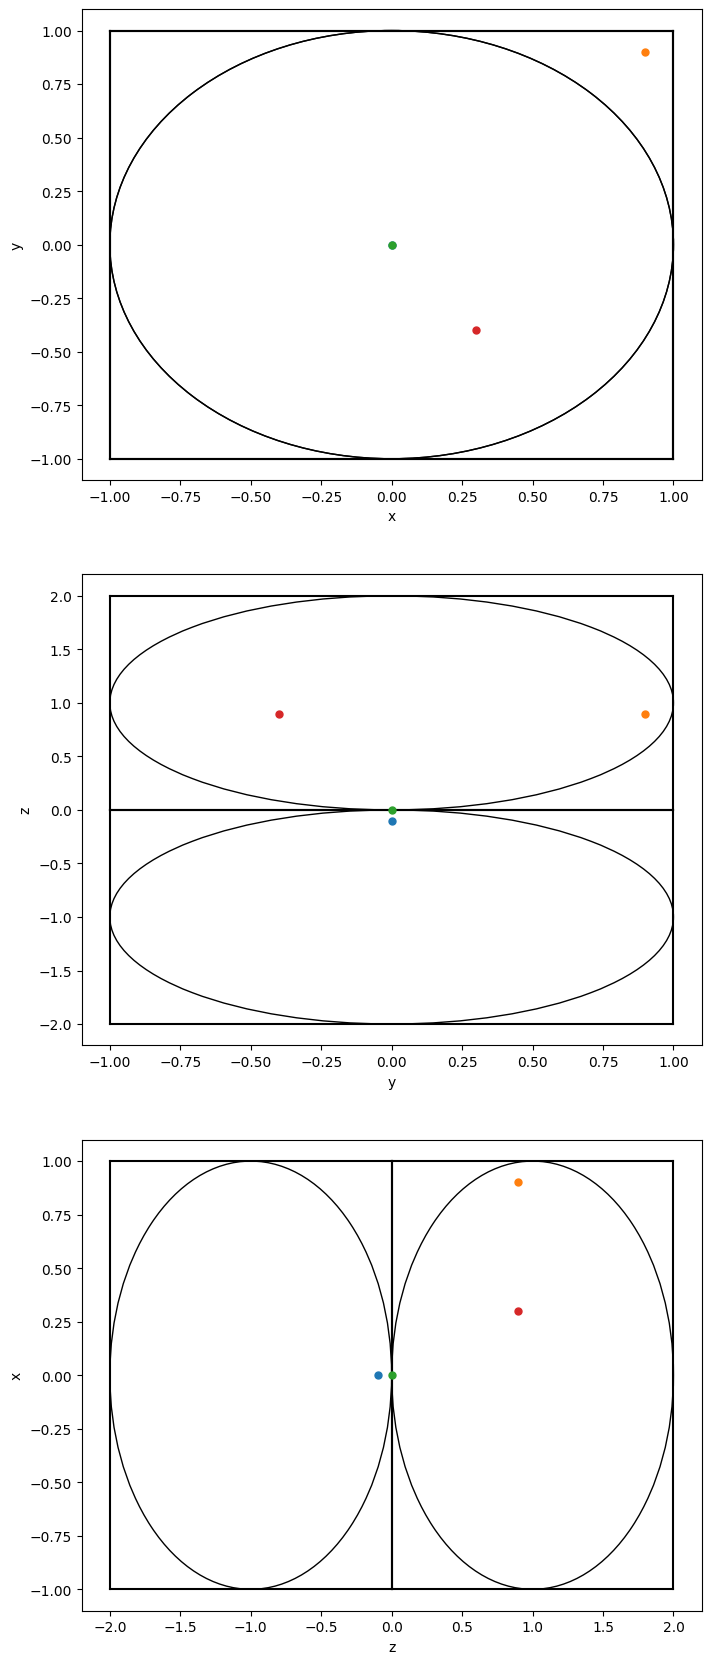

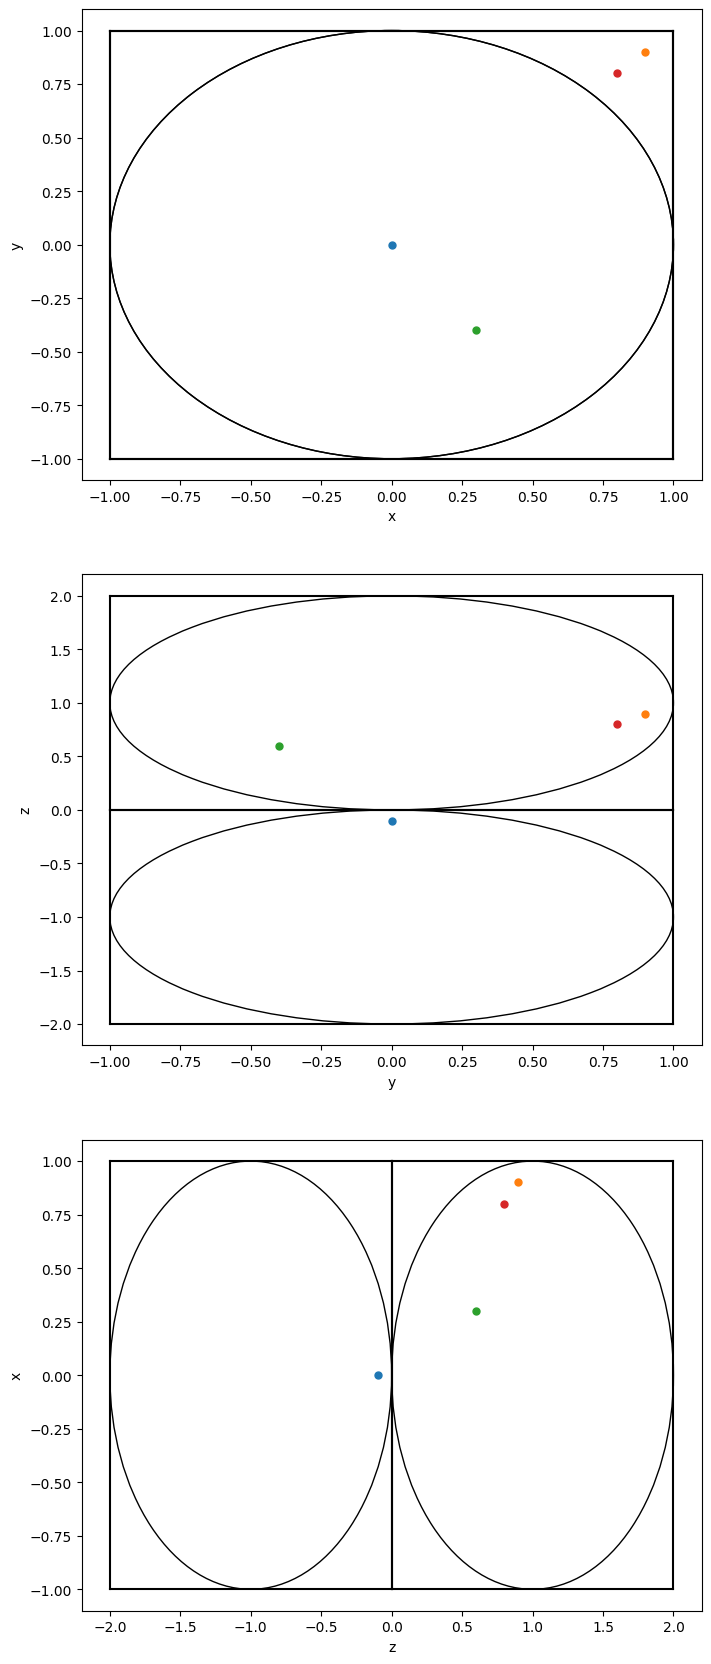

In [9]:
vht = volumeHT([-1, 1, -1, 1, -2, 2], 2, 30, boxes.augOverlapBox, ['3', '4'])
fig, ax = constructorChecker(vht)
part1 = redsim.molecule(numpy.array([0.9, 0.9, 0.9]), '3')
print("part1 " + str(vht.put(part1)))
part2 = redsim.molecule(numpy.array([0, 0, 0.0]), '3')
print("part2: " + str(vht.put(part2)))
part3 = redsim.molecule(numpy.array([0.3, -0.4, 0.9]), '4')
print("part3: " + str(vht.put(part3)))
part4 = redsim.molecule(numpy.array([0, 0, -0.1]), '3')
print("part4: " + str(vht.put(part4)))
drawParticles2D(ax, vht)
print("\n")
boxChecker(vht)

print(vht.attemptMove(part3, numpy.array([0.3, -0.4, 0.95])))
print(vht.attemptMove(part3, numpy.array([0.3, -0.4, 0.6])))
print(vht.attemptMove(part2, numpy.array([0.8, 0.8, 0.8])))
fig, ax = constructorChecker(vht)
drawParticles2D(ax, vht)
print("\n")
boxChecker(vht)

actual density: 2.6666666666666665
side lengths: (1.0, 1.0, 1.3333333333333333)
number of boxes per dimension(2, 2, 3)
part1 True
part2: True
part3: True
part4: True
[ 0.3 -0.4  0.9]
[0. 0. 0.]
[ 0.   0.  -0.1]
[0.9 0.9 0.9]
[<redoxSimulation.molecule object at 0x13fea2940>, <redoxSimulation.molecule object at 0x1541f50d0>, <redoxSimulation.molecule object at 0x13fe15a00>, <redoxSimulation.molecule object at 0x1541ab2e0>]
[<boxes.augOverlapBox object at 0x13fbf9a30>, <boxes.augOverlapBox object at 0x13fbf9be0>, <boxes.augOverlapBox object at 0x13fbf9a90>, <boxes.augOverlapBox object at 0x1540dc0a0>, <boxes.augOverlapBox object at 0x1540dc100>, <boxes.augOverlapBox object at 0x1540eafa0>, <boxes.augOverlapBox object at 0x13fcf97c0>, <boxes.augOverlapBox object at 0x13fcf96a0>, <boxes.augOverlapBox object at 0x13fcf9760>, <boxes.augOverlapBox object at 0x13fcf4c10>, <boxes.augOverlapBox object at 0x13fcf4b50>]


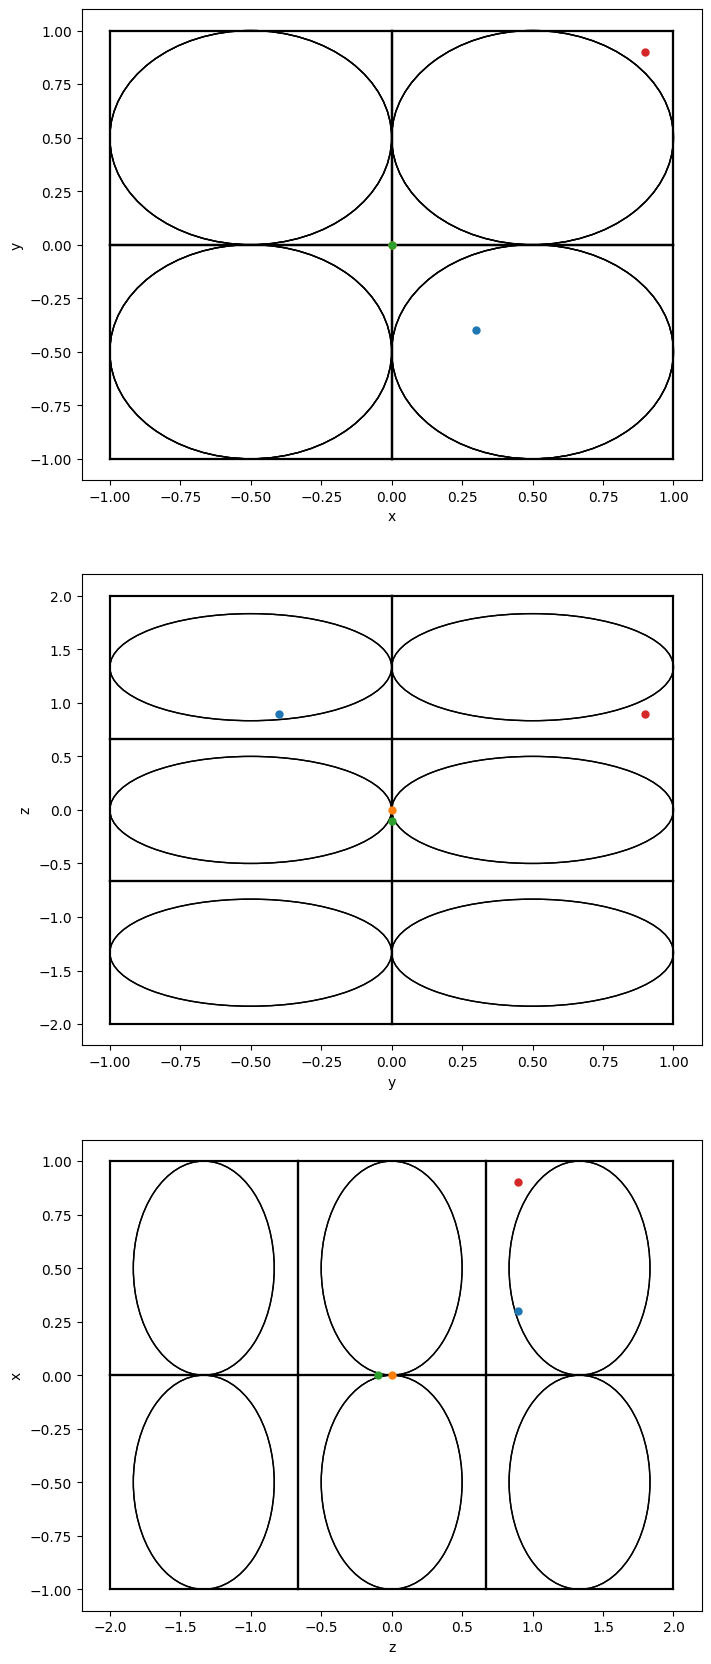

In [10]:
vht = volumeHT([-1, 1, -1, 1, -2, 2], 2, 4, boxes.augOverlapBox, ['3', '4'])
fig, ax = constructorChecker(vht)
part1 = redsim.molecule(numpy.array([0.9, 0.9, 0.9]), '3')
print("part1 " + str(vht.put(part1)))
part2 = redsim.molecule(numpy.array([0, 0, 0.0]), '3')
print("part2: " + str(vht.put(part2)))
part3 = redsim.molecule(numpy.array([0.3, -0.4, 0.9]), '4')
print("part3: " + str(vht.put(part3)))
part4 = redsim.molecule(numpy.array([0, 0, -0.1]), '3')
print("part4: " + str(vht.put(part4)))
drawParticles2D(ax, vht)
print(vht.contents())
print(vht.adjacent(vht.boxDict[(0, 0, 1)]))


actual density: 1.3333333333333333
side lengths: (0.6666666666666666, 0.6666666666666666, 0.75)
number of boxes per dimension(3, 3, 4)

 checking contents()
done checking contents 

checking adjacent()
(1, 1, 1)
	 (0, 0, 0)	(-0.6666666666666667, -0.6666666666666667, 0.375)
	 (0, 0, 1)	(-0.6666666666666667, -0.6666666666666667, 1.125)
	 (0, 0, 2)	(-0.6666666666666667, -0.6666666666666667, 1.875)
	 (0, 1, 0)	(-0.6666666666666667, -5.551115123125783e-17, 0.375)
	 (0, 1, 1)	(-0.6666666666666667, -5.551115123125783e-17, 1.125)
	 (0, 1, 2)	(-0.6666666666666667, -5.551115123125783e-17, 1.875)
	 (0, 2, 0)	(-0.6666666666666667, 0.6666666666666665, 0.375)
	 (0, 2, 1)	(-0.6666666666666667, 0.6666666666666665, 1.125)
	 (0, 2, 2)	(-0.6666666666666667, 0.6666666666666665, 1.875)
	 (1, 0, 0)	(-5.551115123125783e-17, -0.6666666666666667, 0.375)
	 (1, 0, 1)	(-5.551115123125783e-17, -0.6666666666666667, 1.125)
	 (1, 0, 2)	(-5.551115123125783e-17, -0.6666666666666667, 1.875)
	 (1, 1, 0)	(-5.5511151231257

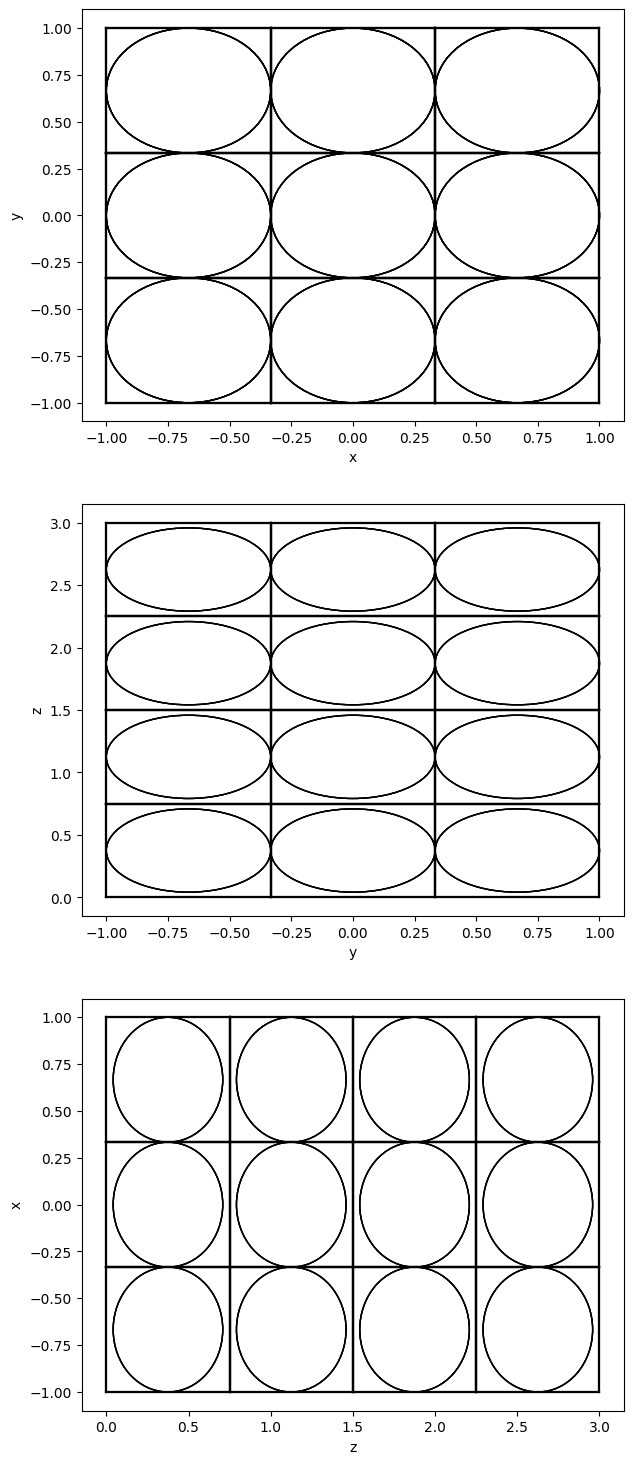

In [11]:
vht = volumeHT([-1, 1, -1, 1, 0, 3], 4, 2, boxes.augRadiusBox, ['3', '4'])
fig, ax = constructorChecker(vht)

print("\n checking contents()")
cont = vht.contents()
for part in cont:   
    print(part.pos, part.rad, part.species)
print("done checking contents \n")

print("checking adjacent()")
print("(1, 1, 1)")
adj = vht.adjacent(vht.boxDict[(1, 1, 1)])
for a in adj:
    print("\t " + str(a.boxNumber) + "\t" + str(a.center))
print(len(adj))

drawParticles2D(ax, vht)
print("\n")
augBoxChecker(vht)